In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv(
    "../data/processed/ecommerce_churn_cleaned.csv"
)

print("Shape:", df.shape)

df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [4]:
df["Churn"].value_counts()

Churn
0    4682
1     948
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

In [6]:
y = df["Churn"]

In [7]:
X = df.drop(
    columns=["Churn", "CustomerID"]
)

In [8]:
categorical_cols = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Numerical columns:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


C:\Users\hemag\AppData\Local\Temp\ipykernel_31432\1532111971.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4504, 18)
X_test : (1126, 18)
y_train: (4504,)
y_test : (1126,)


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/ecommerce_churn_cleaned.csv"
)

print(df.shape)

(5630, 20)


In [12]:
import sys

sys.path.append("../src")

from feature_engineering import create_features

In [13]:
df_features = create_features(df)

df_features.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderFrequency,CouponUsageRate,RecencyCategory,DevicePerTenure
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,...,1,11.0,1.0,1.0,5.0,159.93,0.250000,1.0,0-7 days,0.750000
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,...,1,15.0,0.0,1.0,0.0,120.90,0.111111,0.0,0-7 days,0.444444
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,...,1,14.0,0.0,1.0,3.0,120.28,0.111111,0.0,0-7 days,0.444444
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,0,23.0,0.0,1.0,3.0,134.07,NaN,0.0,0-7 days,NaN
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,...,0,11.0,1.0,1.0,3.0,129.60,NaN,1.0,0-7 days,NaN


In [14]:
new_features = [
    "OrderFrequency",
    "CouponUsageRate",
    "RecencyCategory",
    "DevicePerTenure"
]

df_features[new_features].head(10)

,OrderFrequency,CouponUsageRate,RecencyCategory,DevicePerTenure
0,0.250000,1.000000,0-7 days,0.750000
1,0.111111,0.000000,0-7 days,0.444444
2,0.111111,0.000000,0-7 days,0.444444
3,NaN,0.000000,0-7 days,NaN
4,NaN,1.000000,0-7 days,NaN
5,NaN,0.666667,0-7 days,NaN
6,0.111111,0.000000,0-7 days,0.333333
7,0.222222,1.000000,0-7 days,0.333333
8,0.076923,0.000000,0-7 days,0.307692
9,0.111111,1.000000,0-7 days,0.555556


In [15]:
print(df_features.shape)

(5630, 24)


In [16]:
df_features[new_features].isnull().sum()

OrderFrequency     508
CouponUsageRate      0
RecencyCategory      0
DevicePerTenure    508
dtype: int64

In [17]:
df_features[
    [
        "Tenure",
        "OrderCount",
        "OrderFrequency",
        "CouponUsed",
        "CouponUsageRate",
        "DaySinceLastOrder",
        "RecencyCategory",
        "NumberOfDeviceRegistered",
        "DevicePerTenure"
    ]
].head(10)

,Tenure,OrderCount,OrderFrequency,CouponUsed,CouponUsageRate,DaySinceLastOrder,RecencyCategory,NumberOfDeviceRegistered,DevicePerTenure
0,4.0,1.0,0.250000,1.0,1.000000,5.0,0-7 days,3,0.750000
1,9.0,1.0,0.111111,0.0,0.000000,0.0,0-7 days,4,0.444444
2,9.0,1.0,0.111111,0.0,0.000000,3.0,0-7 days,4,0.444444
3,0.0,1.0,NaN,0.0,0.000000,3.0,0-7 days,4,NaN
4,0.0,1.0,NaN,1.0,1.000000,3.0,0-7 days,3,NaN
5,0.0,6.0,NaN,4.0,0.666667,7.0,0-7 days,5,NaN
6,9.0,1.0,0.111111,0.0,0.000000,0.0,0-7 days,3,0.333333
7,9.0,2.0,0.222222,2.0,1.000000,0.0,0-7 days,3,0.333333
8,13.0,1.0,0.076923,0.0,0.000000,2.0,0-7 days,4,0.307692
9,9.0,1.0,0.111111,1.0,1.000000,1.0,0-7 days,5,0.555556


In [18]:
X = df_features.drop(
    columns=["Churn", "CustomerID"]
)

y = df_features["Churn"]

In [19]:
numeric_features = X.select_dtypes(
    include=np.number
)

corr_matrix = numeric_features.corr()

corr_matrix

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderFrequency,CouponUsageRate,DevicePerTenure
Tenure,1.000000,-0.057895,-0.012191,-0.017282,-0.020657,-0.014452,0.235076,-0.020535,-0.005542,0.101535,0.165339,0.174378,0.467986,-0.469365,0.027420,-0.620306
CityTier,-0.057895,1.000000,0.013576,-0.009921,0.027934,-0.011554,-0.029440,0.003375,-0.028890,0.022629,0.033551,0.010214,0.055746,0.038926,-0.009571,0.034200
WarehouseToHome,-0.012191,0.013576,1.000000,0.064069,0.023020,0.007524,-0.008305,0.026825,0.038311,0.002675,0.000354,0.020253,0.000415,0.041544,0.019401,0.049944
HourSpendOnApp,-0.017282,-0.009921,0.064069,1.000000,0.305048,0.030937,0.139541,0.006607,0.099305,0.187166,0.102053,0.061213,0.114286,0.166970,0.155287,0.211772
NumberOfDeviceRegistered,-0.020657,0.027934,0.023020,0.305048,1.000000,-0.017228,0.084997,0.003407,0.065714,0.152065,0.099790,0.007350,0.137183,0.167148,0.107733,0.338860
SatisfactionScore,-0.014452,-0.011554,0.007524,0.030937,-0.017228,1.000000,0.053583,-0.031115,-0.027121,0.017423,0.018166,0.031985,0.003473,0.027172,0.015292,0.047184
NumberOfAddress,0.235076,-0.029440,-0.008305,0.139541,0.084997,0.053583,1.000000,-0.026399,0.012161,0.036985,-0.013970,-0.067180,0.186688,-0.087953,0.090453,-0.084478
Complain,-0.020535,0.003375,0.026825,0.006607,0.003407,-0.031115,-0.026399,1.000000,-0.003842,-0.007810,-0.021288,-0.041415,0.000525,0.073433,0.001015,0.069924
OrderAmountHikeFromlastYear,-0.005542,-0.028890,0.038311,0.099305,0.065714,-0.027121,0.012161,-0.003842,1.000000,0.024482,0.010567,-0.004621,-0.009620,0.047934,0.036490,0.057611
CouponUsed,0.101535,0.022629,0.002675,0.187166,0.152065,0.017423,0.036985,-0.007810,0.024482,1.000000,0.641178,0.296816,0.219394,0.267462,0.493870,0.006428


In [20]:
numeric_features = X.select_dtypes(
    include=np.number
)

corr_matrix = numeric_features.corr()

corr_matrix

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,OrderFrequency,CouponUsageRate,DevicePerTenure
Tenure,1.000000,-0.057895,-0.012191,-0.017282,-0.020657,-0.014452,0.235076,-0.020535,-0.005542,0.101535,0.165339,0.174378,0.467986,-0.469365,0.027420,-0.620306
CityTier,-0.057895,1.000000,0.013576,-0.009921,0.027934,-0.011554,-0.029440,0.003375,-0.028890,0.022629,0.033551,0.010214,0.055746,0.038926,-0.009571,0.034200
WarehouseToHome,-0.012191,0.013576,1.000000,0.064069,0.023020,0.007524,-0.008305,0.026825,0.038311,0.002675,0.000354,0.020253,0.000415,0.041544,0.019401,0.049944
HourSpendOnApp,-0.017282,-0.009921,0.064069,1.000000,0.305048,0.030937,0.139541,0.006607,0.099305,0.187166,0.102053,0.061213,0.114286,0.166970,0.155287,0.211772
NumberOfDeviceRegistered,-0.020657,0.027934,0.023020,0.305048,1.000000,-0.017228,0.084997,0.003407,0.065714,0.152065,0.099790,0.007350,0.137183,0.167148,0.107733,0.338860
SatisfactionScore,-0.014452,-0.011554,0.007524,0.030937,-0.017228,1.000000,0.053583,-0.031115,-0.027121,0.017423,0.018166,0.031985,0.003473,0.027172,0.015292,0.047184
NumberOfAddress,0.235076,-0.029440,-0.008305,0.139541,0.084997,0.053583,1.000000,-0.026399,0.012161,0.036985,-0.013970,-0.067180,0.186688,-0.087953,0.090453,-0.084478
Complain,-0.020535,0.003375,0.026825,0.006607,0.003407,-0.031115,-0.026399,1.000000,-0.003842,-0.007810,-0.021288,-0.041415,0.000525,0.073433,0.001015,0.069924
OrderAmountHikeFromlastYear,-0.005542,-0.028890,0.038311,0.099305,0.065714,-0.027121,0.012161,-0.003842,1.000000,0.024482,0.010567,-0.004621,-0.009620,0.047934,0.036490,0.057611
CouponUsed,0.101535,0.022629,0.002675,0.187166,0.152065,0.017423,0.036985,-0.007810,0.024482,1.000000,0.641178,0.296816,0.219394,0.267462,0.493870,0.006428


In [21]:
y.value_counts()

Churn
0    4682
1     948
Name: count, dtype: int64

In [22]:
y.value_counts(normalize=True) * 100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

In [23]:
df_features = create_features(df)

In [24]:
print(df_features.shape)

(5630, 24)


In [25]:
df_features[new_features].head()

,OrderFrequency,CouponUsageRate,RecencyCategory,DevicePerTenure
0,0.250000,1.0,0-7 days,0.750000
1,0.111111,0.0,0-7 days,0.444444
2,0.111111,0.0,0-7 days,0.444444
3,NaN,0.0,0-7 days,NaN
4,NaN,1.0,0-7 days,NaN


In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/ecommerce_churn_cleaned.csv"
)

print(df.shape)

(5630, 20)


In [27]:
import sys

sys.path.append("../src")

from feature_engineering import create_features

In [28]:
df_features = create_features(df)

print("Original shape:", df.shape)
print("After feature engineering:", df_features.shape)

Original shape: (5630, 20)
After feature engineering: (5630, 24)


In [29]:
y = df_features["Churn"]

In [30]:
print(y.head())
print("\nTarget distribution:")
print(y.value_counts())

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

Target distribution:
Churn
0    4682
1     948
Name: count, dtype: int64


In [31]:
X = df_features.drop(
    columns=["Churn", "CustomerID"]
)

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5630, 22)
y shape: (5630,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
print("Training features :", X_train.shape)
print("Testing features  :", X_test.shape)
print("Training target   :", y_train.shape)
print("Testing target    :", y_test.shape)

Training features : (4504, 22)
Testing features  : (1126, 22)
Training target   : (4504,)
Testing target    : (1126,)


In [35]:
print("Overall:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)

Overall:
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

Training:
Churn
0    83.170515
1    16.829485
Name: proportion, dtype: float64

Testing:
Churn
0    83.12611
1    16.87389
Name: proportion, dtype: float64


In [36]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nMajority class:")
print(y_train.mode()[0])

Training target distribution:
Churn
0    3746
1     758
Name: count, dtype: int64

Majority class:
0


In [37]:
majority_class = y_train.mode()[0]

y_pred_baseline = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

In [38]:
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print("Majority Class Baseline Accuracy:", baseline_accuracy)

Majority Class Baseline Accuracy: 0.8312611012433393


In [39]:
categorical_cols = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Numerical columns:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'OrderFrequency', 'CouponUsageRate', 'DevicePerTenure']


C:\Users\hemag\AppData\Local\Temp\ipykernel_31432\1532111971.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [42]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [43]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [44]:
from sklearn.linear_model import LogisticRegression

logistic_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [45]:
logistic_baseline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Tenure','PreferredLoginDevice','CityTier',...,'CouponUsageRate', 'RecencyCategory','DevicePerTenure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [46]:
y_pred_logistic = logistic_baseline.predict(
    X_test
)

In [48]:
y_prob_logistic = logistic_baseline.predict_proba(
    X_test
)[:, 1]

In [49]:
baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic),
    "Recall": recall_score(y_test, y_pred_logistic),
    "F1": f1_score(y_test, y_pred_logistic),
    "ROC-AUC": roc_auc_score(y_test, y_prob_logistic)
}

baseline_results

{'Accuracy': 0.8916518650088809,
 'Precision': 0.7394366197183099,
 'Recall': 0.5526315789473685,
 'F1': 0.6325301204819277,
 'ROC-AUC': 0.8896367521367521}

In [50]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[899  37]
 [ 85 105]]


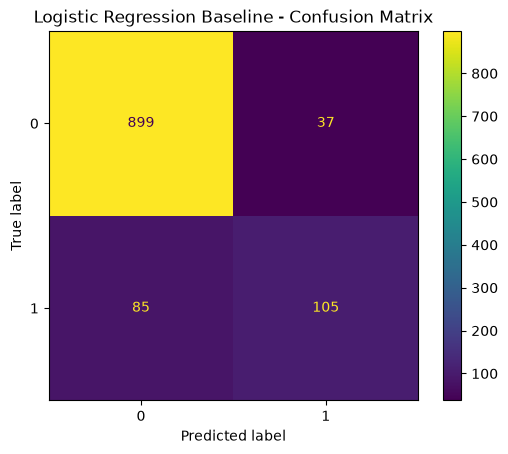

In [52]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title("Logistic Regression Baseline - Confusion Matrix")
plt.show()

In [53]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Active", "Churned"]
    )
)

              precision    recall  f1-score   support

      Active       0.91      0.96      0.94       936
     Churned       0.74      0.55      0.63       190

    accuracy                           0.89      1126
   macro avg       0.83      0.76      0.78      1126
weighted avg       0.88      0.89      0.89      1126



In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [55]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [56]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [57]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [58]:
print(trained_models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])


In [59]:
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(X_test)

    print(
        f"{name}: {len(predictions[name])} predictions"
    )

Logistic Regression: 1126 predictions
Decision Tree: 1126 predictions
Random Forest: 1126 predictions
Gradient Boosting: 1126 predictions


In [60]:
probabilities = {}

for name, model in trained_models.items():

    probabilities[name] = model.predict_proba(X_test)[:, 1]

In [61]:
print("Random Forest predictions:")
print(predictions["Random Forest"][:10])

Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0]


In [62]:
print("Random Forest probabilities:")
print(probabilities["Random Forest"][:10])

Random Forest probabilities:
[0.01 0.02 0.01 0.   0.07 0.01 0.06 0.   0.06 0.01]


In [63]:
model_summary = pd.DataFrame({
    "Model": list(trained_models.keys()),
    "Status": ["Trained"] * len(trained_models)
})

model_summary

,Model,Status
0,Logistic Regression,Trained
1,Decision Tree,Trained
2,Random Forest,Trained
3,Gradient Boosting,Trained


In [64]:
trained_models["Logistic Regression"]
trained_models["Decision Tree"]
trained_models["Random Forest"]
trained_models["Gradient Boosting"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Tenure','PreferredLoginDevice','CityTier',...,'CouponUsageRate', 'RecencyCategory','DevicePerTenure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [65]:
predictions
probabilities

{'Logistic Regression': array([0.00223298, 0.02171927, 0.00602528, ..., 0.07787348, 0.01231069,
        0.01437867], shape=(1126,)),
 'Decision Tree': array([0., 0., 0., ..., 0., 0., 0.], shape=(1126,)),
 'Random Forest': array([0.01, 0.02, 0.01, ..., 0.06, 0.  , 0.06], shape=(1126,)),
 'Gradient Boosting': array([0.02163549, 0.02553249, 0.01638227, ..., 0.11028633, 0.01765326,
        0.04774437], shape=(1126,))}

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [67]:
def evaluate_model(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    }

    return metrics

In [68]:
results = []

for name, model in trained_models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

In [69]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.891652,0.739437,0.552632,0.632530,0.889637
1,Decision Tree,0.962700,0.877551,0.905263,0.891192,0.939811
2,Random Forest,0.974245,0.982036,0.863158,0.918768,0.998187
3,Gradient Boosting,0.920071,0.824675,0.668421,0.738372,0.945040


In [70]:
results_display = results_df.copy()

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

results_display[metric_cols] = results_display[
    metric_cols
].round(4)

results_display

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8917,0.7394,0.5526,0.6325,0.8896
1,Decision Tree,0.9627,0.8776,0.9053,0.8912,0.9398
2,Random Forest,0.9742,0.9820,0.8632,0.9188,0.9982
3,Gradient Boosting,0.9201,0.8247,0.6684,0.7384,0.9450


In [71]:
results_display.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.9742,0.9820,0.8632,0.9188,0.9982
3,Gradient Boosting,0.9201,0.8247,0.6684,0.7384,0.9450
1,Decision Tree,0.9627,0.8776,0.9053,0.8912,0.9398
0,Logistic Regression,0.8917,0.7394,0.5526,0.6325,0.8896


In [72]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Active", "Churned"],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      Active       0.91      0.96      0.94       936
     Churned       0.74      0.55      0.63       190

    accuracy                           0.89      1126
   macro avg       0.83      0.76      0.78      1126
weighted avg       0.88      0.89      0.89      1126

Decision Tree
              precision    recall  f1-score   support

      Active       0.98      0.97      0.98       936
     Churned       0.88      0.91      0.89       190

    accuracy                           0.96      1126
   macro avg       0.93      0.94      0.93      1126
weighted avg       0.96      0.96      0.96      1126

Random Forest
              precision    recall  f1-score   support

      Active       0.97      1.00      0.98       936
     Churned       0.98      0.86      0.92       190

    accuracy                           0.97      1126
   macro avg       0.98      0.93      0.95      1126
weighted avg       0.97   

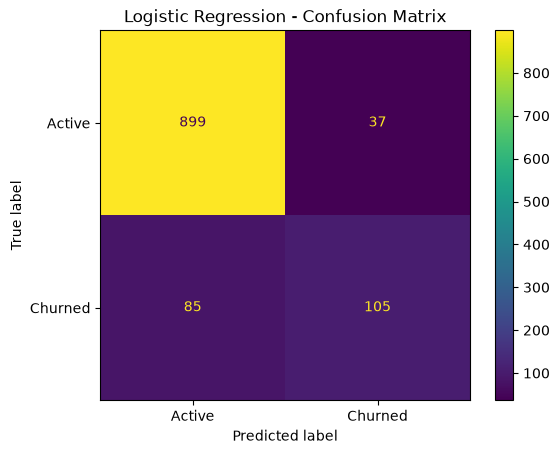

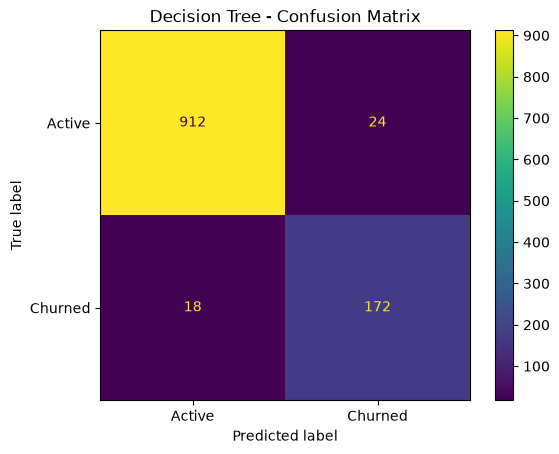

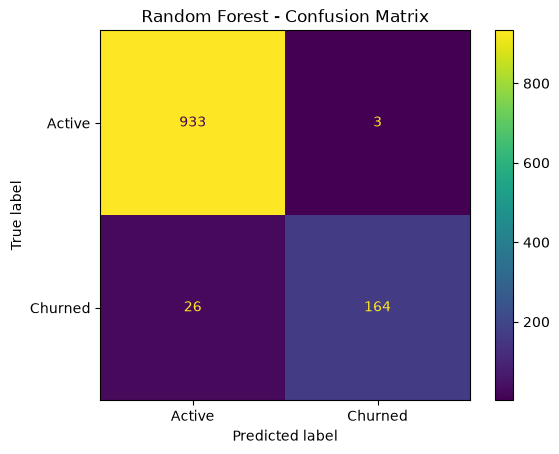

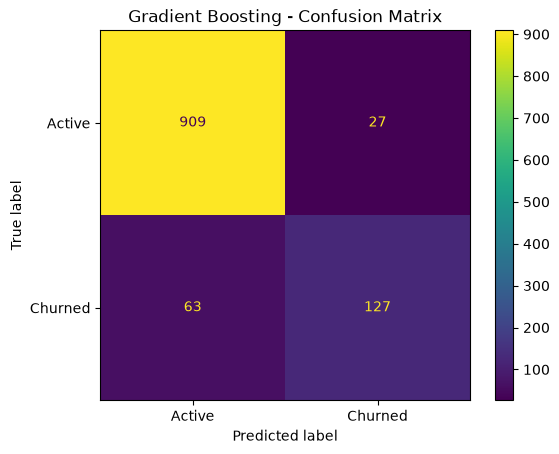

In [73]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Active", "Churned"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

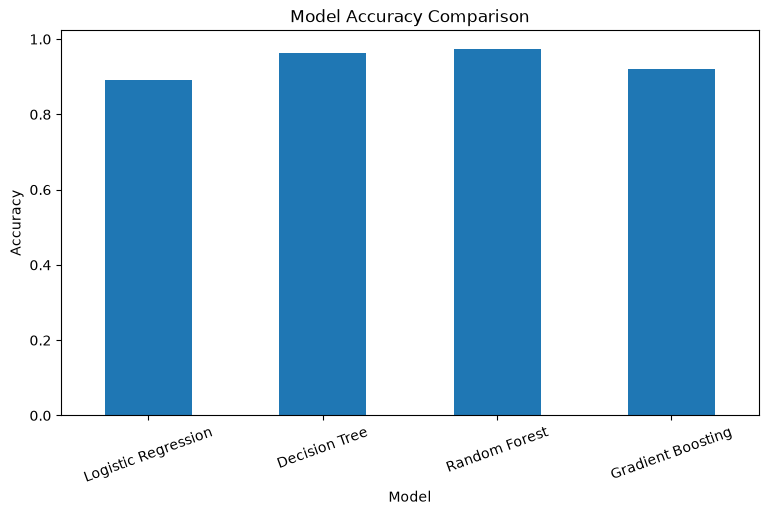

In [74]:
results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.show()

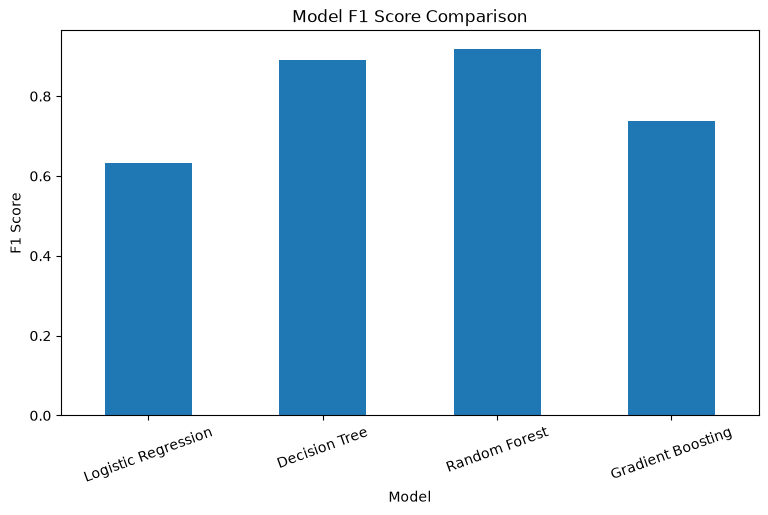

In [75]:
results_df.plot(
    x="Model",
    y="F1",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.show()

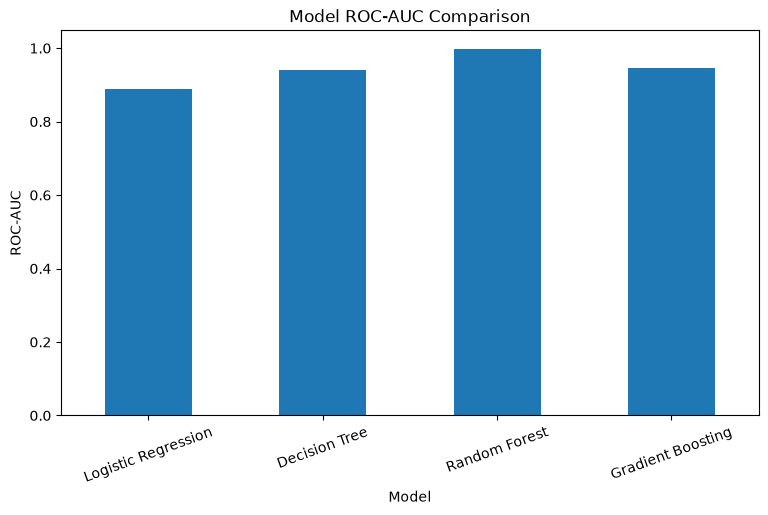

In [76]:
results_df.plot(
    x="Model",
    y="ROC-AUC",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.show()

In [77]:
results_df[
    ["Model", "Recall"]
].sort_values(
    by="Recall",
    ascending=False
)

,Model,Recall
1,Decision Tree,0.905263
2,Random Forest,0.863158
3,Gradient Boosting,0.668421
0,Logistic Regression,0.552632


In [78]:
results_df[
    ["Model", "Precision", "Recall", "F1"]
].sort_values(
    by="F1",
    ascending=False
)

,Model,Precision,Recall,F1
2,Random Forest,0.982036,0.863158,0.918768
1,Decision Tree,0.877551,0.905263,0.891192
3,Gradient Boosting,0.824675,0.668421,0.738372
0,Logistic Regression,0.739437,0.552632,0.632530


In [79]:
results_df.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

In [80]:
candidate_name = "Random Forest"

In [81]:
from sklearn.model_selection import RandomizedSearchCV

In [82]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [83]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [84]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [85]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` c

In [86]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}


In [87]:
print("Best CV F1 Score:")
print(random_search.best_score_)

Best CV F1 Score:
0.8579185033981782


In [88]:
tuned_model = random_search.best_estimator_

In [89]:
y_pred_tuned = tuned_model.predict(X_test)

In [90]:
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

In [91]:
tuned_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_tuned
    ),

    "Precision": precision_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_tuned
    )
}

tuned_results

{'Accuracy': 0.9857904085257548,
 'Precision': 0.967741935483871,
 'Recall': 0.9473684210526315,
 'F1': 0.9574468085106383,
 'ROC-AUC': 0.9973712325686009}

In [92]:
rf_before = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

In [93]:
before_after = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Before Tuning": [
        rf_before["Accuracy"],
        rf_before["Precision"],
        rf_before["Recall"],
        rf_before["F1"],
        rf_before["ROC-AUC"]
    ],

    "After Tuning": [
        tuned_results["Accuracy"],
        tuned_results["Precision"],
        tuned_results["Recall"],
        tuned_results["F1"],
        tuned_results["ROC-AUC"]
    ]
})

before_after.round(4)

,Metric,Before Tuning,After Tuning
0,Accuracy,0.9742,0.9858
1,Precision,0.9820,0.9677
2,Recall,0.8632,0.9474
3,F1,0.9188,0.9574
4,ROC-AUC,0.9982,0.9974


In [94]:
before_after["Improvement"] = (
    before_after["After Tuning"]
    - before_after["Before Tuning"]
)

before_after.round(4)

,Metric,Before Tuning,After Tuning,Improvement
0,Accuracy,0.9742,0.9858,0.0115
1,Precision,0.9820,0.9677,-0.0143
2,Recall,0.8632,0.9474,0.0842
3,F1,0.9188,0.9574,0.0387
4,ROC-AUC,0.9982,0.9974,-0.0008


In [95]:
cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results[
    [
        "mean_test_score",
        "std_test_score",
        "params"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,params
13,0.857919,0.012444,"{'model__n_estimators': 400, 'model__min_sampl..."
1,0.853912,0.011077,"{'model__n_estimators': 200, 'model__min_sampl..."
5,0.833904,0.016751,"{'model__n_estimators': 200, 'model__min_sampl..."
3,0.813228,0.013986,"{'model__n_estimators': 300, 'model__min_sampl..."
12,0.813197,0.014032,"{'model__n_estimators': 300, 'model__min_sampl..."
4,0.810426,0.015498,"{'model__n_estimators': 200, 'model__min_sampl..."
2,0.805027,0.010895,"{'model__n_estimators': 200, 'model__min_sampl..."
10,0.793016,0.018485,"{'model__n_estimators': 300, 'model__min_sampl..."
7,0.772474,0.015529,"{'model__n_estimators': 300, 'model__min_sampl..."
18,0.771586,0.016766,"{'model__n_estimators': 300, 'model__min_sampl..."


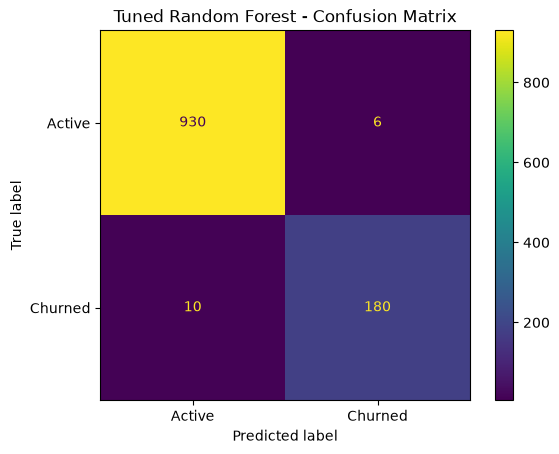

In [96]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=["Active", "Churned"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [100]:
import os
import joblib

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(
    tuned_model,
    "../artifacts/tuned_random_forest_pipeline.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [102]:
import os

print(os.path.exists(
    "../artifacts/tuned_random_forest_pipeline.joblib"
))

True


In [101]:
import joblib

joblib.dump(
    tuned_model,
    "../artifacts/tuned_random_forest_pipeline.joblib"
)

['../artifacts/tuned_random_forest_pipeline.joblib']

In [104]:
import os
print(os.getcwd())

d:\GEN_AI\E-Commerce\notebooks


In [105]:
print(tuned_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'CityTier',
                                                   'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'SatisfactionScore',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFr

In [106]:
rf_model = tuned_model.named_steps["model"]

print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [107]:
feature_names = (
    tuned_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of transformed features:", len(feature_names))

Number of transformed features: 37


In [108]:
feature_names[:20]

array(['num__Tenure', 'num__CityTier', 'num__WarehouseToHome',
       'num__HourSpendOnApp', 'num__NumberOfDeviceRegistered',
       'num__SatisfactionScore', 'num__NumberOfAddress', 'num__Complain',
       'num__OrderAmountHikeFromlastYear', 'num__CouponUsed',
       'num__OrderCount', 'num__DaySinceLastOrder', 'num__CashbackAmount',
       'num__OrderFrequency', 'num__CouponUsageRate',
       'num__DevicePerTenure', 'cat__PreferredLoginDevice_Computer',
       'cat__PreferredLoginDevice_Mobile Phone',
       'cat__PreferredLoginDevice_Phone', 'cat__PreferredPaymentMode_CC'],
      dtype=object)

In [109]:
importances = rf_model.feature_importances_

print("Number of importances:", len(importances))

Number of importances: 37


In [110]:
print(len(feature_names))
print(len(importances))

37
37


In [111]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [112]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

In [113]:
feature_importance_df.head(20)

,Feature,Importance
0,num__Tenure,0.253270
1,num__CashbackAmount,0.086900
2,num__NumberOfAddress,0.073968
3,num__WarehouseToHome,0.065790
4,num__Complain,0.062727
5,num__DaySinceLastOrder,0.057320
6,num__SatisfactionScore,0.048462
7,num__OrderAmountHikeFromlastYear,0.044802
8,num__NumberOfDeviceRegistered,0.027224
9,num__DevicePerTenure,0.025649


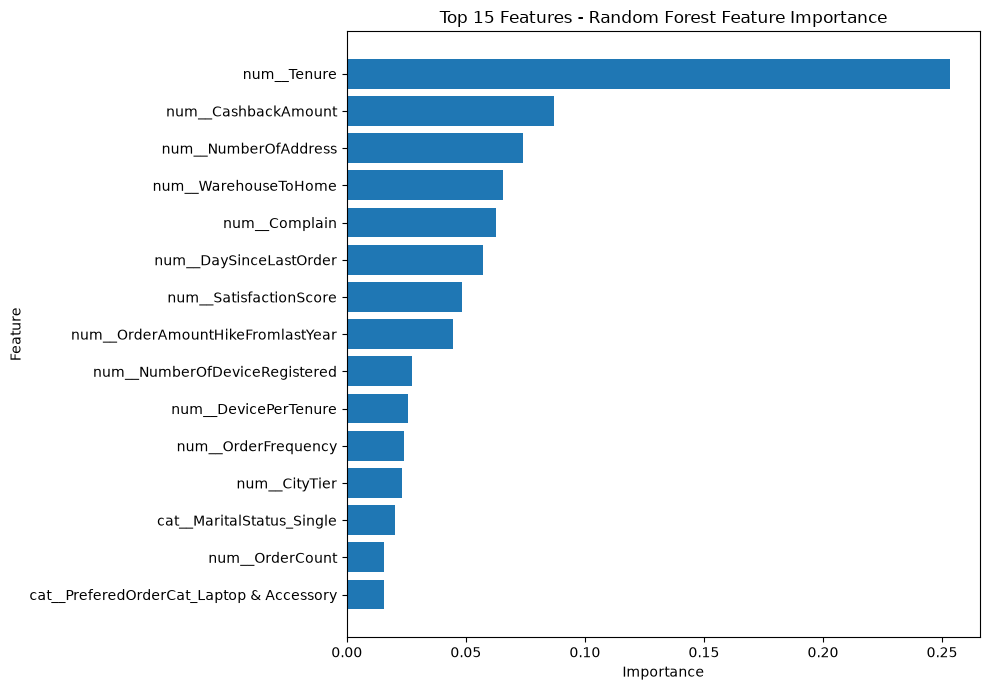

In [114]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Features - Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [115]:
feature_importance_df.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [116]:
feature_importance_df.head(10)

,Feature,Importance
0,num__Tenure,0.253270
1,num__CashbackAmount,0.086900
2,num__NumberOfAddress,0.073968
3,num__WarehouseToHome,0.065790
4,num__Complain,0.062727
5,num__DaySinceLastOrder,0.057320
6,num__SatisfactionScore,0.048462
7,num__OrderAmountHikeFromlastYear,0.044802
8,num__NumberOfDeviceRegistered,0.027224
9,num__DevicePerTenure,0.025649


In [117]:
logistic_model = trained_models["Logistic Regression"].named_steps["model"]

logistic_features = (
    trained_models["Logistic Regression"]
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = logistic_model.coef_[0]

logistic_coef_df = pd.DataFrame({
    "Feature": logistic_features,
    "Coefficient": coefficients
})

logistic_coef_df["AbsoluteCoefficient"] = (
    logistic_coef_df["Coefficient"].abs()
)

logistic_coef_df = logistic_coef_df.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

logistic_coef_df.head(20)

,Feature,Coefficient,AbsoluteCoefficient
33,cat__PreferedOrderCat_Others,1.801349,1.801349
30,cat__PreferedOrderCat_Laptop & Accessory,-1.727220,1.727220
0,num__Tenure,-1.494834,1.494834
32,cat__PreferedOrderCat_Mobile Phone,-0.798736,0.798736
7,num__Complain,0.783344,0.783344
12,num__CashbackAmount,-0.771091,0.771091
6,num__NumberOfAddress,0.601903,0.601903
35,cat__MaritalStatus_Married,-0.589665,0.589665
26,cat__Gender_Female,-0.492085,0.492085
5,num__SatisfactionScore,0.431490,0.431490


In [118]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

In [119]:
import sys
sys.path.append("../src")

from feature_engineering import create_features

In [120]:
df_final = pd.read_csv(
    "../data/processed/ecommerce_churn_cleaned.csv"
)

X_raw = df_final.drop(
    columns=["Churn", "CustomerID"]
)

y_final = df_final["Churn"]

In [121]:
X_train_raw, X_test_raw, y_train_final, y_test_final = train_test_split(
    X_raw,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

In [122]:
feature_engineering_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [123]:
X_train_engineered = create_features(X_train_raw)

print(X_train_engineered.shape)
print(X_train_engineered.columns.tolist())

(4504, 22)
['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'OrderFrequency', 'CouponUsageRate', 'RecencyCategory', 'DevicePerTenure']


In [124]:
final_categorical_cols = X_train_engineered.select_dtypes(
    include="object"
).columns.tolist()

final_categorical_cols += [
    "RecencyCategory"
]

final_categorical_cols = list(
    dict.fromkeys(final_categorical_cols)
)

final_numerical_cols = X_train_engineered.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical:")
print(final_categorical_cols)

print("\nNumerical:")
print(final_numerical_cols)

Categorical:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus', 'RecencyCategory']

Numerical:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'OrderFrequency', 'CouponUsageRate', 'DevicePerTenure']


C:\Users\hemag\AppData\Local\Temp\ipykernel_31432\1430201053.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  final_categorical_cols = X_train_engineered.select_dtypes(


In [125]:
final_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

final_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [126]:
final_preprocessor = ColumnTransformer([
    (
        "num",
        final_numeric_pipeline,
        final_numerical_cols
    ),
    (
        "cat",
        final_categorical_pipeline,
        final_categorical_cols
    )
])

In [127]:
random_search.best_params_

{'model__n_estimators': 400,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_features': None,
 'model__max_depth': None}

In [128]:
print(random_search.best_params_)

{'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}


In [129]:
final_rf = random_search.best_estimator_.named_steps["model"]

In [130]:
final_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_engineering_transformer
    ),
    (
        "preprocessor",
        final_preprocessor
    ),
    (
        "model",
        final_rf
    )
])

In [131]:
final_pipeline.fit(
    X_train_raw,
    y_train_final
)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [132]:
final_pred = final_pipeline.predict(
    X_test_raw
)

final_prob = final_pipeline.predict_proba(
    X_test_raw
)[:, 1]

In [133]:
final_results = {
    "Accuracy": accuracy_score(
        y_test_final,
        final_pred
    ),
    "Precision": precision_score(
        y_test_final,
        final_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_final,
        final_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_final,
        final_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_final,
        final_prob
    )
}

final_results

{'Accuracy': 0.9857904085257548,
 'Precision': 0.967741935483871,
 'Recall': 0.9473684210526315,
 'F1': 0.9574468085106383,
 'ROC-AUC': 0.9973881016644175}

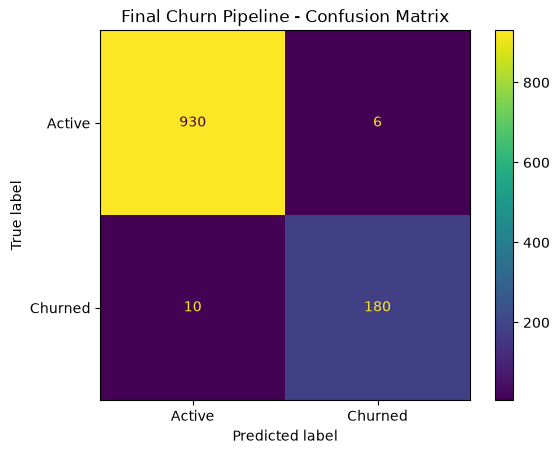

In [134]:
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    final_pred,
    display_labels=["Active", "Churned"]
)

plt.title("Final Churn Pipeline - Confusion Matrix")
plt.show()

In [135]:
print("Final Pipeline Performance")
print("--------------------------")

for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Final Pipeline Performance
--------------------------
Accuracy: 0.9858
Precision: 0.9677
Recall: 0.9474
F1: 0.9574
ROC-AUC: 0.9974


In [136]:
sample_customer = X_test_raw.iloc[[0]]

In [137]:
sample_prediction = final_pipeline.predict(
    sample_customer
)

sample_probability = final_pipeline.predict_proba(
    sample_customer
)[:, 1][0]

print("Prediction:", sample_prediction[0])
print("Churn Probability:", round(sample_probability, 4))

Prediction: 0
Churn Probability: 0.025


In [138]:
prediction = int(sample_prediction[0])
probability = float(sample_probability)

if prediction == 1:
    status = "High Risk"
else:
    status = "Low Risk"

print("Prediction:", prediction)
print("Status:", status)
print("Churn Probability:", round(probability, 4))

Prediction: 0
Status: Low Risk
Churn Probability: 0.025


In [139]:
test_customer = X_test_raw.iloc[[0]].copy()

test_customer["DaySinceLastOrder"] = 70
test_customer["SatisfactionScore"] = 2
test_customer["Complain"] = 1

In [140]:
prediction = final_pipeline.predict(
    test_customer
)[0]

probability = final_pipeline.predict_proba(
    test_customer
)[:, 1][0]

print("Prediction:", int(prediction))
print("Churn Probability:", round(float(probability), 4))

Prediction: 0
Churn Probability: 0.075


In [141]:
import os
import joblib

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(
    final_pipeline,
    "../artifacts/churn_pipeline.joblib"
)

print("Final churn pipeline saved successfully!")

Final churn pipeline saved successfully!


In [142]:
import os

print(
    os.path.exists(
        "../artifacts/churn_pipeline.joblib"
    )
)

True


In [143]:
sample = X_test_raw.iloc[0]

print(sample.to_dict())

{'Tenure': 17.0, 'PreferredLoginDevice': 'Computer', 'CityTier': 3, 'WarehouseToHome': 9.0, 'PreferredPaymentMode': 'Debit Card', 'Gender': 'Male', 'HourSpendOnApp': 4.0, 'NumberOfDeviceRegistered': 4, 'PreferedOrderCat': 'Laptop & Accessory', 'SatisfactionScore': 1, 'MaritalStatus': 'Married', 'NumberOfAddress': 3, 'Complain': 0, 'OrderAmountHikeFromlastYear': 21.0, 'CouponUsed': 6.0, 'OrderCount': 8.0, 'DaySinceLastOrder': 8.0, 'CashbackAmount': 181.75}
